In [3]:
import os 
from pathlib import Path

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from helper import * 

from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.metrics import recall_score, accuracy_score, f1_score, roc_auc_score, roc_curve, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier


from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

current_dir = Path.cwd()  
PROJECT_ROOT = current_dir.parent.parent

df = pd.read_csv(PROJECT_ROOT/'data'/'processed'/'Cleaned_csv.csv')

df = df.drop(labels=['Unnamed: 0'], axis=1)
df = df.rename(columns=lambda x: x.replace('remainder__', ''))
df.head()

,encoder__City_Los Angeles,encoder__City_Other,encoder__City_San Diego,encoder__City_San Francisco,encoder__Gender_Female,encoder__Gender_Male,encoder__Senior Citizen_No,encoder__Senior Citizen_Yes,encoder__Dependents_No,encoder__Dependents_Yes,...,encoder__Paperless Billing_Yes,encoder__Payment Method_Bank transfer (automatic),encoder__Payment Method_Credit card (automatic),encoder__Payment Method_Electronic check,encoder__Payment Method_Mailed check,Tenure Months,Monthly Charges,Total Charges,Churn Value,CLTV
0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,2.0,53.85,108.15,1.0,3239.0
1,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,2.0,70.70,151.65,1.0,2701.0
2,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,8.0,99.65,820.50,1.0,5372.0
3,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,28.0,104.80,3046.05,1.0,5003.0
4,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,49.0,103.70,5036.30,1.0,5340.0


In [4]:
X = df.drop(labels=['Churn Value'], axis=1)
y = df['Churn Value']

rf = RandomForestClassifier()

pipeline = build_PipieLine(rf, X, y)

pipeline.train()

Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('model_RandomForestClassifier', RandomForestClassifier())])

Accuracy: 0.793
Recall: 0.553
F1: 0.586


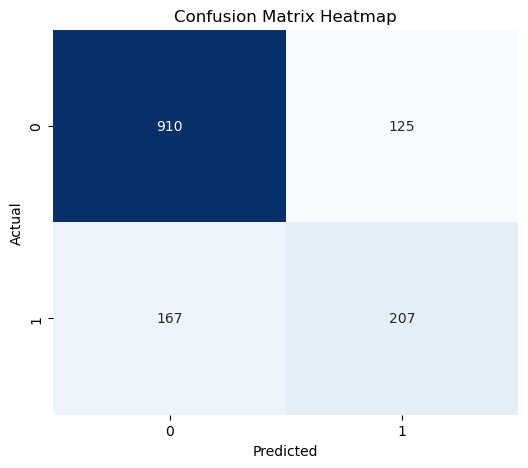

In [5]:
pipeline.evaluate(pipeline.pipeline)

In [6]:
# Cross-validation 

params = {
    "model_RandomForestClassifier__n_estimators": [100, 300, 500],
    "model_RandomForestClassifier__max_depth": [5, 10, 20, None],
    "model_RandomForestClassifier__min_samples_leaf": [1, 2, 5],
    "model_RandomForestClassifier__class_weight": [None, "balanced"]
}

cv = pipeline.cv(params)

{'model_RandomForestClassifier__class_weight': None, 'model_RandomForestClassifier__max_depth': 5, 'model_RandomForestClassifier__min_samples_leaf': 2, 'model_RandomForestClassifier__n_estimators': 100}
0.7083612040133779


In [7]:
print(cv.best_params_)
print(cv.best_score_)

{'model_RandomForestClassifier__class_weight': None, 'model_RandomForestClassifier__max_depth': 5, 'model_RandomForestClassifier__min_samples_leaf': 2, 'model_RandomForestClassifier__n_estimators': 100}
0.7083612040133779


In [8]:
y_pred = cv.predict(pipeline.X_test)

accuracy = accuracy_score(pipeline.y_test, y_pred)
recall = recall_score(pipeline.y_test, y_pred)
f1 = f1_score(pipeline.y_test, y_pred)

models_df = pd.DataFrame({
    'Model': ['RandomForest'],
    'Accuracy': [round(accuracy, 3)],
    'Recall': [round(recall, 3)],
    'F1':[round(f1,3)]
})

models_df.to_csv(PROJECT_ROOT/'data'/'processed'/'model_results.csv', mode="a", index=False, header=False)

In [9]:
models_df = pd.read_csv(PROJECT_ROOT/'data'/'processed'/'model_results.csv')
models_df.head()

,Model,Accuracy,Recall,F1
0,Baseline Model (Logistic Regression),0.751,0.808,0.648
1,Decision Trees,0.753,0.730,0.611
2,RandomForest,0.781,0.690,0.625
